In [1]:
from stress_risk.utils.data import get_all_behavior
from tms_risk.utils.data import Subject as TMSSubject
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/Users/gdehol/mambaforge/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '


In [2]:
# sub 01 - > sub-32
df_tms = TMSSubject('01').get_behavior()
order = df_tms.index.names
df_tms = df_tms.reset_index('subject')
df_tms['subject'] = 32
df_tms = df_tms.set_index('subject', append=True).reorder_levels(order)

In [3]:
df = get_all_behavior()
df = pd.concat((df, df_tms))

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_49387/3842034007.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  data=df.groupby(['subject', 'n_safe', 'risky_first']).mean().reset_index(), kind='point', ci=67)
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_49387/3842034007.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 67)` for the same effect.

  sns.catplot(x='n_safe', y='chose_risky', hue='risky_first',


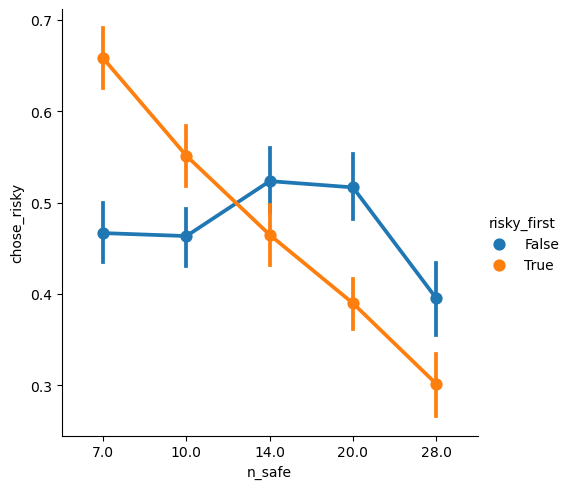

In [4]:
sns.catplot(x='n_safe', y='chose_risky', hue='risky_first',
data=df.groupby(['subject', 'n_safe', 'risky_first']).mean().reset_index(), kind='point', ci=67)

In [5]:
import bambi

In [6]:
df['x'] = df['log(risky/safe)']

In [7]:
model = bambi.Model('chose_risky ~ x + (x|subject)', link='probit', family='bernoulli', data=df.reset_index())

In [8]:
traces = model.fit(init='adapt_diag', target_accept=0.9, draws=500, tune=500)

Modeling the probability that chose_risky==1
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, x, 1|subject_sigma, 1|subject_offset, x|subject_sigma, x|subject_offset]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 35 seconds.


In [9]:
import scipy.stats as ss
def invprobit(x):
    return ss.norm.ppf(x)

In [10]:
def extract_rnp_precision(trace, model, data, group=False):

    data = data.reset_index()

    if group:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique()[[0]],
                                                [0, 1],
                                                data['n_safe'].unique(),
                                                [False, True]],
                                                names=['subject', 'x', 'n_safe', 'risky_first']
                                                ).to_frame().reset_index(drop=True)
    else:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique(),
                                                [0, 1],
                                                data['n_safe'].unique(),
                                                [False, True]],
                                                names=['subject', 'x', 'n_safe', 'risky_first']
                                                ).to_frame().reset_index(drop=True)

    pred = model.predict(trace, 'mean', fake_data, inplace=False)['posterior']['chose_risky_mean']

    pred = pred.to_dataframe().unstack([0, 1])
    pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

    # return pred

    pred0 = pred.xs(0, 0, 'x')
    intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
    gamma = invprobit(pred.xs(1, 0, 'x')) - intercept

    return intercept, gamma

In [11]:
import arviz as az

array([[<AxesSubplot: title={'center': 'Intercept'}>,
        <AxesSubplot: title={'center': 'Intercept'}>],
       [<AxesSubplot: title={'center': 'x'}>,
        <AxesSubplot: title={'center': 'x'}>],
       [<AxesSubplot: title={'center': '1|subject_sigma'}>,
        <AxesSubplot: title={'center': '1|subject_sigma'}>],
       [<AxesSubplot: title={'center': 'x|subject_sigma'}>,
        <AxesSubplot: title={'center': 'x|subject_sigma'}>],
       [<AxesSubplot: title={'center': '1|subject'}>,
        <AxesSubplot: title={'center': '1|subject'}>],
       [<AxesSubplot: title={'center': 'x|subject'}>,
        <AxesSubplot: title={'center': 'x|subject'}>]], dtype=object)

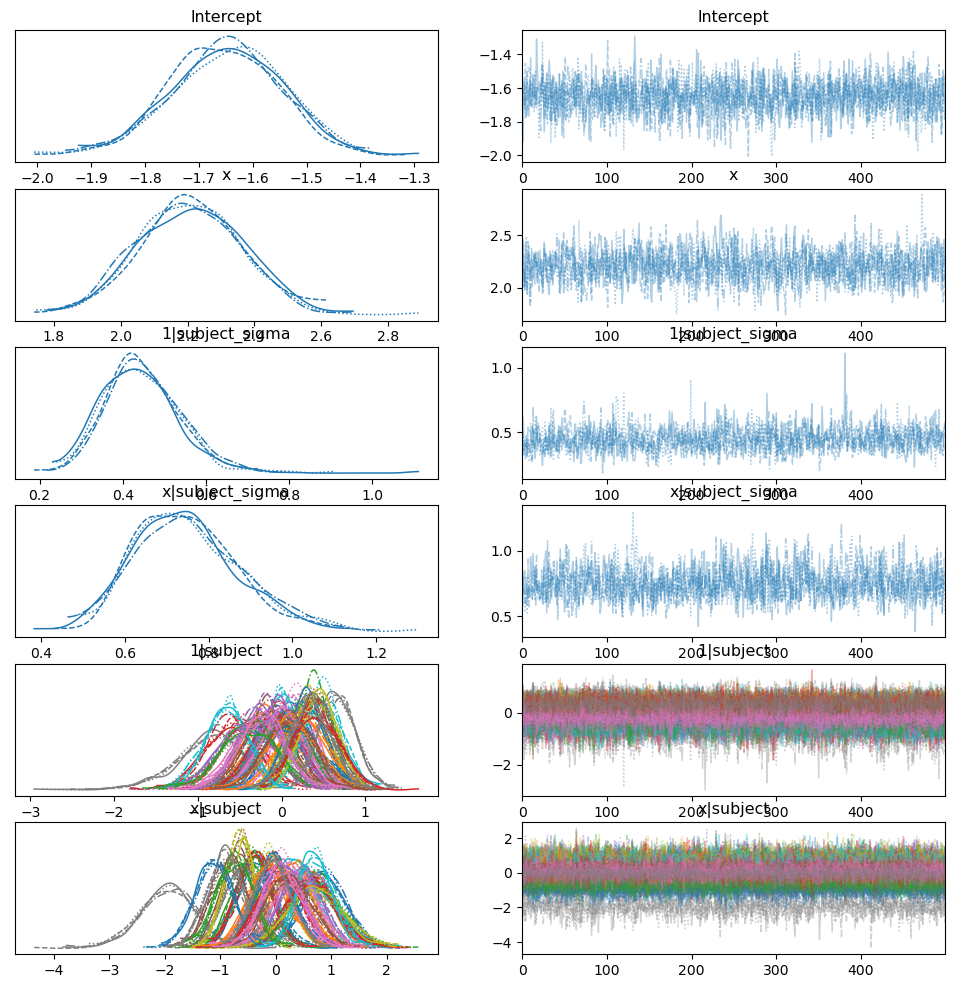

In [12]:
az.plot_trace(traces)

In [13]:
intercept, gamma = extract_rnp_precision(traces, model, df, False)

/Users/gdehol/mambaforge/lib/python3.10/site-packages/pandas/core/internals/blocks.py:352: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


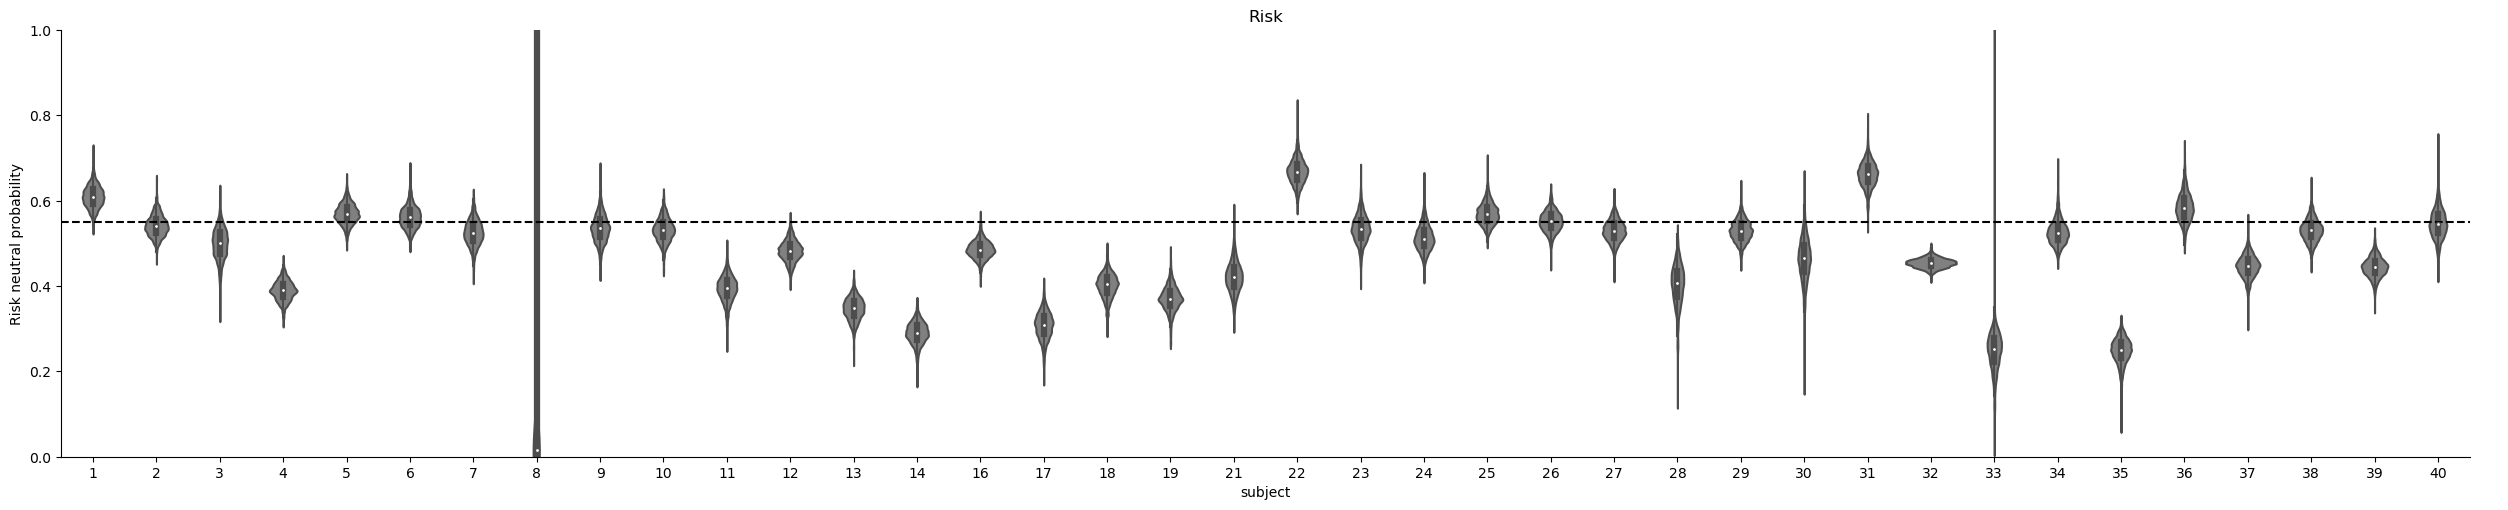

In [20]:
import numpy as np

rnp = np.clip(np.exp(intercept/gamma), 0, 1)

rnp = rnp.stack([1,2])
rnp.columns = ['rnp']

fac = sns.catplot(x='subject', y='rnp', data=rnp.reset_index(), aspect=5., kind='violin', color='gray')
plt.ylim(0, 1)
plt.axhline(.55, c='k', ls='--', label='risk-neutral')
fac.set(title='Risk', ylabel='Risk neutral probability')
fac.add_legend()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_49387/48917856.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(rnp.groupby('subject').mean(), bins=25)


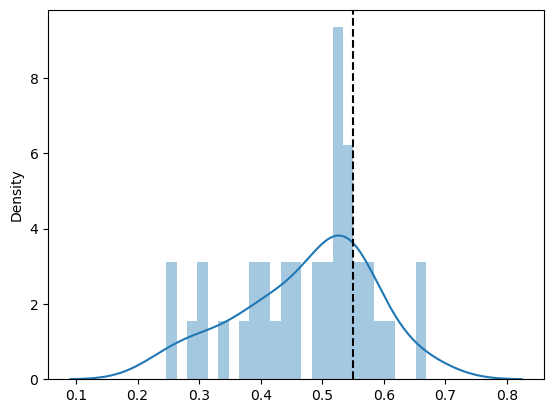

In [15]:
sns.distplot(rnp.groupby('subject').mean(), bins=25)
plt.axvline(.55, c='k', ls='--')

In [21]:
rnp.groupby('subject').mean().to_csv('subjectwise_rnp.tsv', sep='\t')